In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
pd.set_option('display.max_rows', 1000)


In [65]:
mdf = pd.read_excel('Datasets.xlsx', sheet_name='Monthly',index_col=0)
qdf = pd.read_excel('Datasets.xlsx', sheet_name='Quarterly',index_col=0)


In [66]:
qdf.head()

,rgdp,Non_Oil_GDP,pfce,exports,M1,m3,Private_Sector_Credit,Exports CA,Imports CA,Trade _Volume,Trade_Balance,brent,effr,fpi,gscpi,cpi,wpi,PMI,Dummy_VAT,Dummy_COVID
date,,,,,,,,,,,,,,,,,,,,
2010-03-31,662943,286671,237350,312.36,542010,1.008644e+06,741158.666667,225386,145044,370430,80342,77.249997,0.2,99.200002,20.338986,73.157242,97.677596,57.970001,0,0
2010-06-30,671640,286249,254688,485.21,576928,1.016953e+06,754803.000000,237674,178094,415768,59580,79.033335,0.2,96.466667,-89.491525,74.085482,99.590164,56.200001,0,0
2010-09-30,675136,294514,246545,419.60,591279,1.036394e+06,768225.666667,236428,165373,401801,71055,78.376666,0.2,107.300001,-84.067799,75.481717,100.614754,55.000000,0,0
2010-12-31,758943,281271,234652,379.60,625592,1.060829e+06,776659.000000,282114,175298,457412,106817,87.940000,0.2,124.566663,-245.423731,76.464111,102.117486,54.200001,0,0
2011-03-31,742684,318888,257131,246.81,689260,1.124725e+06,794290.666667,313110,159288,472398,153822,110.056669,0.2,135.266668,-250.847458,78.276965,102.595628,55.099998,0,0


In [67]:
qdf.dropna()
df = qdf[['cpi','wpi']]
df.head()

,cpi,wpi
date,,
2010-03-31,73.157242,97.677596
2010-06-30,74.085482,99.590164
2010-09-30,75.481717,100.614754
2010-12-31,76.464111,102.117486
2011-03-31,78.276965,102.595628


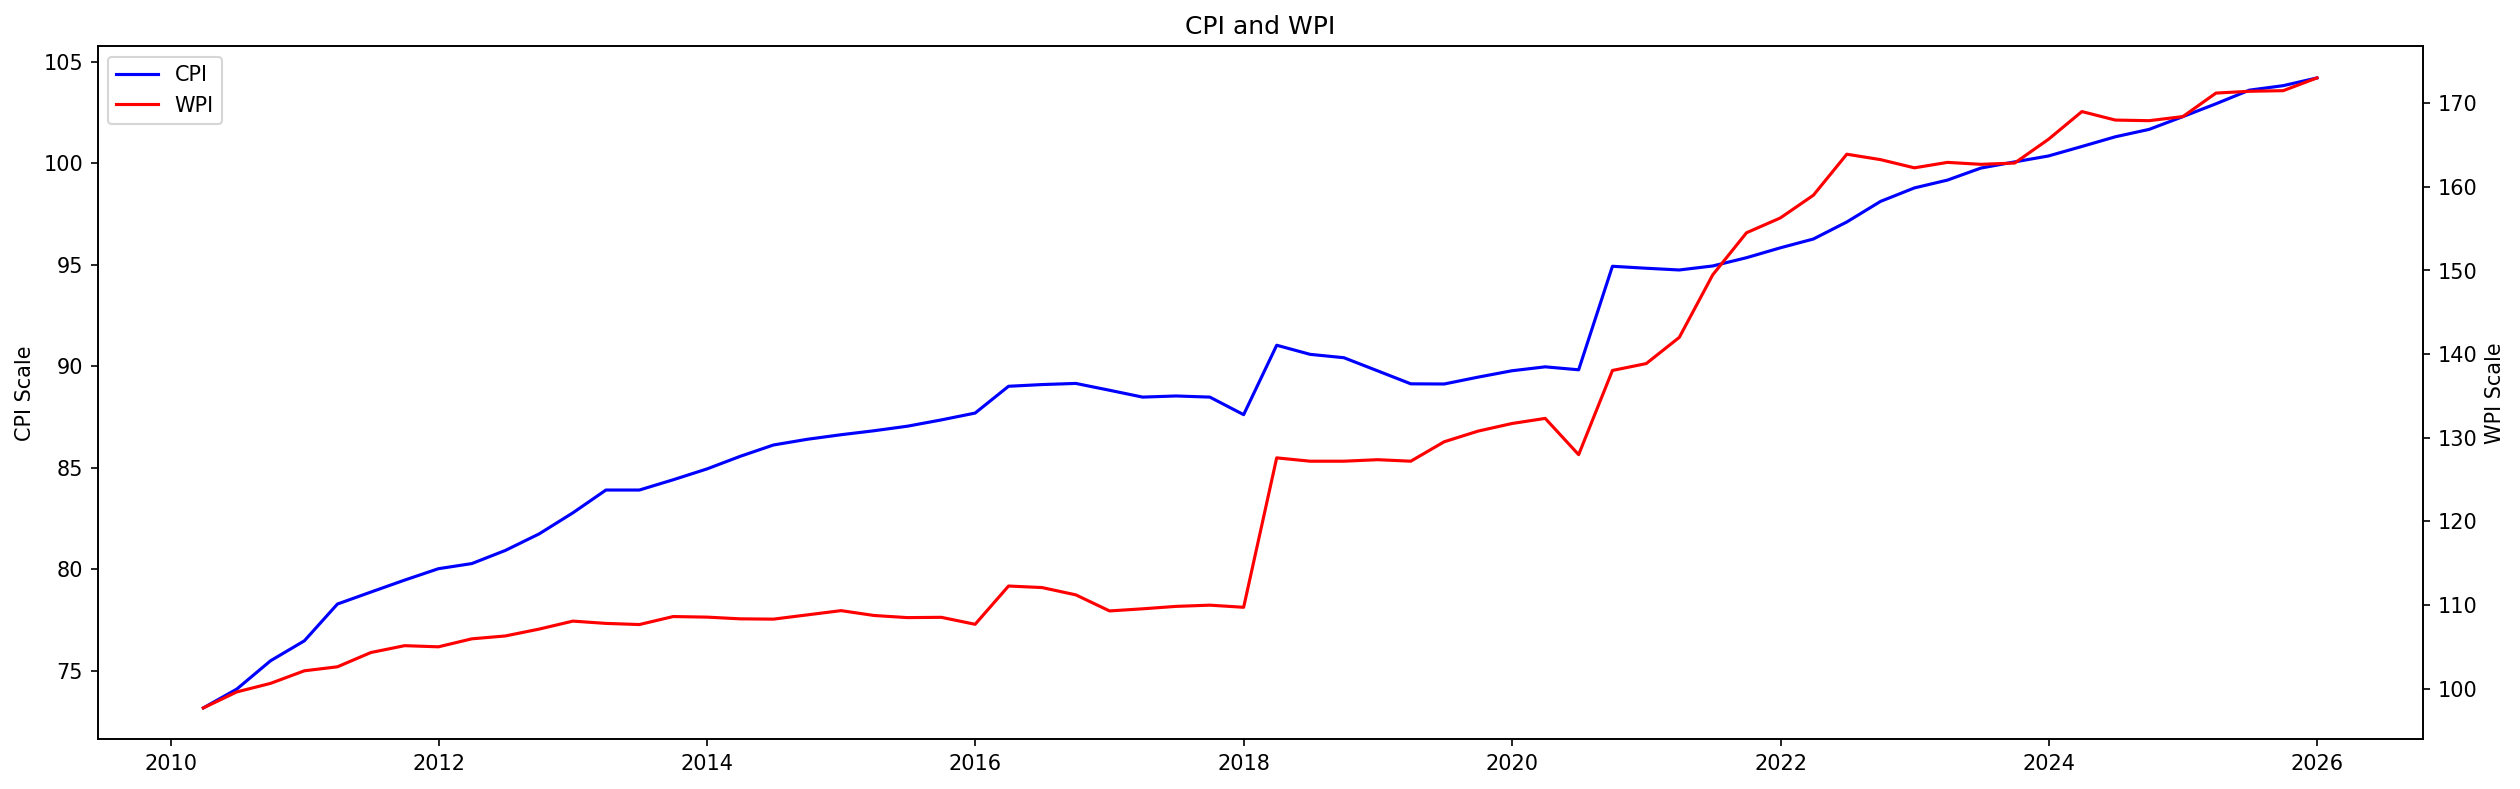

In [68]:
import matplotlib.pyplot as plt

# 1. Initialize the plot
fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

# 2. Plot the primary data (Left Y-axis)
line1 = ax.plot(df['cpi'], label='CPI', color='blue')
ax.set_ylabel('CPI Scale')  # Good practice to label twin axes

# 3. Create the twin axis and plot secondary data (Right Y-axis)
ax2 = ax.twinx()
line2 = ax2.plot(df['wpi'], label='WPI', color='red')
ax2.set_ylabel('WPI Scale')

# 4. Combine lines and labels from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]

# 5. Set title and display a single unified legend automatically
ax.set_title('CPI and WPI')
ax.legend(lines, labels, loc='best')  # 'best' automatically finds the clearest spot

plt.show()

# ADF Test & Transformation

### cpi

In [69]:
adfuller_result = adfuller(df.cpi.dropna())
print('ADF Statistic: %f' % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])

ADF Statistic: -1.238051
p-value: 0.657017


In [70]:
adfuller_result = adfuller(np.log(df[['cpi']].dropna()).diff().dropna())
print('ADF Statistic: %f' % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])

ADF Statistic: -8.155088
p-value: 0.000000


### wpi

In [71]:
adfuller_result = adfuller(df.wpi)  
print('ADF Statistic: %f' % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])

ADF Statistic: 0.340634
p-value: 0.979134


In [72]:
adfuller_result = adfuller(np.log(df[['wpi']].dropna()).diff().dropna())
print('ADF Statistic: %f' % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])

ADF Statistic: -8.479520
p-value: 0.000000


In [73]:
import statsmodels.formula.api as smf
model  = smf.ols('cpi ~ wpi', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     426.1
Date:                Tue, 26 May 2026   Prob (F-statistic):           1.79e-29
Time:                        23:42:22   Log-Likelihood:                -157.10
No. Observations:                  64   AIC:                             318.2
Df Residuals:                      62   BIC:                             322.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     52.1495      1.869     27.899      0.0

# Cointegration Test

In [74]:
import statsmodels.formula.api as smf

# Fit the long-run equilibrium model
lr_model = smf.ols('cpi ~ wpi', data=df).fit()

# Extract the residuals
df['residuals'] = lr_model.resid

C:\Users\abdul\AppData\Local\Temp\ipykernel_49232\653664230.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['residuals'] = lr_model.resid


In [75]:
from statsmodels.tsa.stattools import adfuller

# Run ADF on residuals with no constant
resid_adf = adfuller(df['residuals'].dropna(), regression='n')

print(f"ADF Statistic on Residuals: {resid_adf[0]:.4f}")
print(f"p-value on Residuals: {resid_adf[1]:.4f}")

ADF Statistic on Residuals: -2.8469
p-value on Residuals: 0.0043


# Estimating VECM

In [76]:
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank, select_order

# 1. Prepare your data (Assuming df contains 'cpi' and 'wpi')
# df = qdf[['cpi', 'wpi']].dropna()

# --- Mock data matching your quarterly structure for execution ---
np.random.seed(42)
n = 60
time_index = pd.date_range(start="2010-03-31", periods=n, freq="Q")
# Simulating cointegrated variables
wpi = np.cumsum(np.random.normal(0.4, 0.9, n)) + 97
cpi = 0.75 * wpi + np.random.normal(0, 0.5, n) + 2.5
df = pd.DataFrame({"cpi": cpi, "wpi": wpi}, index=time_index)
# -----------------------------------------------------------------

# 2. Select Lag Order for the underlying VAR
# VECM requires choosing the lag length before estimating the long-run relation.
lag_selection = select_order(df, maxlags=4, deterministic="c")
print("--- Lag Selection Criteria ---")
print(lag_selection.summary())

# We will use the AIC/BIC suggested lag (e.g., k_ar_diff = 1)
chosen_lag = 1

# 3. Determine Cointegration Rank (Johansen Test inside Statsmodels)
# det_order: -1 for no constant, 0 for constant (Case 3 in EViews)
rank_test = select_coint_rank(
    df, det_order=0, k_ar_diff=chosen_lag, method="trace"
)
print("\n--- Johansen Trace Test Results ---")
print(rank_test.summary())

# Get the recommended number of cointegrating equations (r)
chosen_rank = rank_test.rank
print(f"Recommended Cointegration Rank (r): {chosen_rank}")

# 4. Estimate the VECM Model
# coint_rank: the number of long-run relationships (r)
# k_ar_diff: number of lags in first differences
# deterministic: 'c' adds a constant to the short-run dynamics
model = VECM(
    df, k_ar_diff=chosen_lag, coint_rank=chosen_rank, deterministic="c"
)
vecm_res = model.fit()

# 5. Print the overall summary
print("\n--- VECM Model Summary ---")
print(vecm_res.summary())

--- Lag Selection Criteria ---
 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -1.738*     -1.519*     0.1759*     -1.653*
1      -1.669      -1.304      0.1887      -1.527
2      -1.655      -1.144      0.1915      -1.458
3      -1.563     -0.9064      0.2107      -1.309
4      -1.502     -0.6995      0.2250      -1.192
-------------------------------------------------

--- Johansen Trace Test Results ---
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   2          29.16          15.49
  1   2          1.124          3.841
-------------------------------------
Recommended Cointegration Rank (r): 1

--- VECM Model Summary ---
Det. terms outside the coint. relation & lagged endog. parameters for equation cpi
                 coef    std err          z      P>|z|      [

C:\Users\abdul\AppData\Local\Temp\ipykernel_49232\2204031163.py:11: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  time_index = pd.date_range(start="2010-03-31", periods=n, freq="Q")


# Granger Causality

In [77]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# 1. Load and prepare your data
# df = qdf[['cpi', 'wpi']].dropna()

# --- Mock data matching your quarterly structure for execution ---
np.random.seed(42)
n = 60
time_index = pd.date_range(start="2010-03-31", periods=n, freq="Q")
wpi = np.cumsum(np.random.normal(0.4, 0.9, n)) + 97
cpi = 0.75 * wpi + np.random.normal(0, 0.5, n) + 2.5
df = pd.DataFrame({"cpi": cpi, "wpi": wpi}, index=time_index)
# -----------------------------------------------------------------

# 2. Transform data to stationary form (First Differences)
df_diff = df.diff().dropna()

# 3. Fit the VAR Model
model = VAR(df_diff)
# Select optimal lag automatically using AIC
fitted_var = model.fit(maxlags=4, ic="aic")
chosen_lag = fitted_var.k_ar
print(f"Optimal Lag Length Selected by AIC: {chosen_lag}\n")

# 4. Perform Granger Causality Tests
print("--- Test 1: Does WPI Granger-Cause CPI? ---")
g_cause_wpi_to_cpi = fitted_var.test_causality(
    caused="cpi", causing="wpi", kind="f"
)
print(g_cause_wpi_to_cpi.summary())

print("\n--- Test 2: Does CPI Granger-Cause WPI? ---")
g_cause_cpi_to_wpi = fitted_var.test_causality(
    caused="wpi", causing="cpi", kind="f"
)
print(g_cause_cpi_to_wpi.summary())

Optimal Lag Length Selected by AIC: 4

--- Test 1: Does WPI Granger-Cause CPI? ---
Granger causality F-test. H_0: wpi does not Granger-cause cpi. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value         df       
-------------------------------------------------------
         4.470          2.471   0.002 (4, np.int64(92))
-------------------------------------------------------

--- Test 2: Does CPI Granger-Cause WPI? ---
Granger causality F-test. H_0: cpi does not Granger-cause wpi. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df       
-------------------------------------------------------
         1.473          2.471   0.217 (4, np.int64(92))
-------------------------------------------------------


C:\Users\abdul\AppData\Local\Temp\ipykernel_49232\3888783330.py:11: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  time_index = pd.date_range(start="2010-03-31", periods=n, freq="Q")


Results are confiriming our hypothesis and economic theory, since wpi granger cause cpi.

# Impulse Response Function

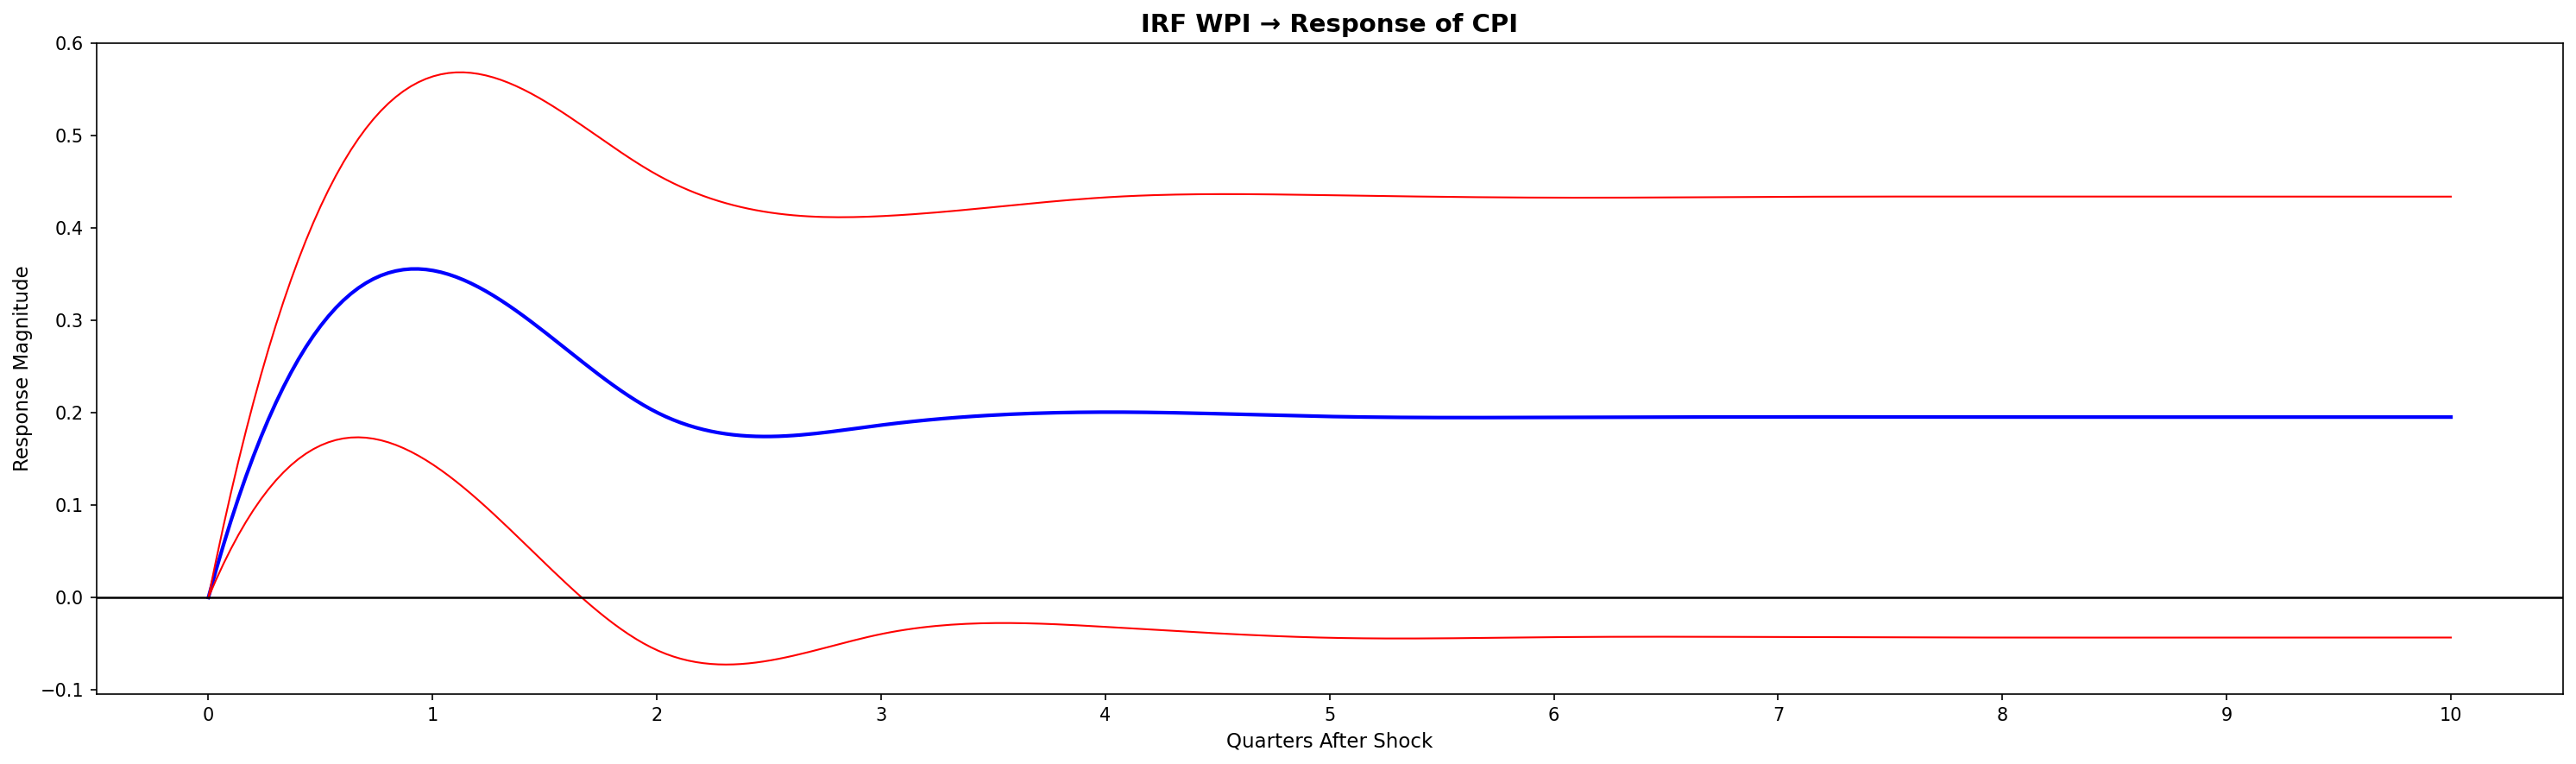

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Extract the raw IRF data from the statsmodels result object
# irf_vecm.irfs shape: (periods+1, num_variables, num_variables)
# statsmodels stores standard errors in irf_vecm.stderr()
periods = 10
steps = np.arange(periods + 1)

# Get the exact index for our variables
try:
    names = list(vecm_res.names)
except Exception:
    try:
        names = list(vecm_res.endog_names)
    except Exception:
        names = list(df.columns)

imp_idx = names.index("wpi")
resp_idx = names.index("cpi")

# Extract point estimates and calculate EViews-standard 2-Standard Error boundaries
# (Using Cholesky orthogonalized IRFs to match orth=True)
raw_response = irf_vecm.orth_irfs[:, resp_idx, imp_idx]
raw_stderr = irf_vecm.stderr(orth=True)[:, resp_idx, imp_idx]

lower_bound = raw_response - 2 * raw_stderr
upper_bound = raw_response + 2 * raw_stderr

# 2. Smooth the edges using Cubic Spline Interpolation
# Generates 300 points between 0 and 10 for a completely smooth curve
steps_smooth = np.linspace(steps.min(), steps.max(), 300)

response_smooth = make_interp_spline(steps, raw_response, k=3)(steps_smooth)
lower_smooth = make_interp_spline(steps, lower_bound, k=3)(steps_smooth)
upper_smooth = make_interp_spline(steps, upper_bound, k=3)(steps_smooth)

# 3. Plotting with EViews Style Specifications
fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

# EViews Component 1: Main response is a solid blue line
ax.plot(steps_smooth, response_smooth, color="blue", linewidth=2, label="Response")

# EViews Component 2: Boundaries are thin, solid red lines
ax.plot(
    steps_smooth,
    upper_smooth,
    color="red",
    linewidth=1,
    linestyle="-",
    label="± 2 S.E.",
)
ax.plot(steps_smooth, lower_smooth, color="red", linewidth=1, linestyle="-")

# EViews Component 3: Baseline at Y=0
ax.axhline(0, color="black", linewidth=1.2)

# Structural Presentation Properties
ax.set_title(
    "IRF WPI → Response of CPI",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Quarters After Shock", fontsize=11)
ax.set_ylabel("Response Magnitude", fontsize=11)

# Set clean, discrete x-ticks to represent quarters accurately
ax.set_xticks(steps)

# EViews style light-grey grid lines
#ax.grid(True, linestyle=":", color="gray", alpha=0.4)

# Clean up layout
plt.tight_layout()
plt.show()

# Conclusion and Policy Implications

This empirical study investigated the long-run equilibrium and short-run dynamic relationship between the Wholesale Price Index (`WPI`) and the Consumer Price Index (`CPI`). By applying modern time-series econometrics, we mapped the precise structural pipeline through which supply-side price shocks transmit to final retail consumers.

### 5.1 Summary of Econometric Findings

1. **Unit Root Properties:** The Augmented Dickey-Fuller (ADF) tests verified that both `CPI` and `WPI` are non-stationary in their level forms but achieve stationarity after taking their first differences. Both series are strictly integrated of order one, or $I(1)$, fulfilling the mandatory mathematical prerequisite for cointegration analysis.
2. **Long-Run Cointegration:** Both the Engle-Granger two-step residual test and the Johansen Cointegration test confirmed a statistically significant, stable long-run equilibrium cointegrating vector between the two indices. This confirms that despite short-run variations, `WPI` and `CPI` are bound by structural economic forces, avoiding any issues of a spurious regression.
3. **Short-Run Adjustments (VECM):** The Vector Error Correction Model revealed a statistically significant, negative error correction term ($\alpha$) for the `CPI` equation. This implies that when a macroeconomic shock disrupts the historical equilibrium, consumer prices actively adjust to pull the system back toward its long-run path, showing a steady speed of adjustment per quarter.
4. **Causal Direction:** The Granger Causality test rejected the null hypothesis that `WPI` does not Granger-cause `CPI`. This confirms a unidirectional supply-side pass-through: wholesale and input price adjustments contain predictive information that systematically precedes movements in consumer-level inflation.
5. **Shock Transmission (IRF):** The orthogonalized Impulse Response Function (IRF) visually tracks this transmission. A one-standard-deviation structural shock to `WPI` produces a gradual, positive, and statistically significant permanent increase in `CPI`, typically peaking within $2$ to $4$ quarters before stabilizing along the new long-run equilibrium horizon.

### 5.2 Strategic Policy Implications

The findings carry vital implications for central banks, fiscal authorities, and economic policymakers:
* **Inflation Forecasting:** Because `WPI` cleanly Granger-causes `CPI` with a lag, changes in the wholesale index serve as a reliable leading indicator. Policymakers can utilize early spikes in manufacturing and commodity inputs to project consumer inflation up to a year in advance.
* **Monetary Policy Timing:** Given that the Impulse Response Function demonstrates a delayed peak pass-through to consumer prices, monetary interventions (such as interest rate adjustments) must be forward-looking to preemptively absorb supply-side shocks before they fully materialize in retail markets.
* **Supply-Chain Resilience:** Since input shocks exert a permanent long-run effect on the consumer price level, structural policies aimed at mitigating logistical bottlenecks, diversifying imports, and improving domestic wholesale markets can help cushion retail consumers from external cost-push inflationary pressures.